<a href="https://colab.research.google.com/github/DeepFluxion/MACK_data-visualization/blob/main/EDA_Reatil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Projeto: Análise Exploratória de Dados de E-commerce
## Etapa 1: Configuração do Ambiente e Carga de Dados

Nesta célula inicial, preparamos o terreno para nossa análise. O objetivo deste script é:

1.  **Importação de Bibliotecas**:
    * `pandas` e `numpy`: Essenciais para manipulação e limpeza de grandes volumes de dados.
    * `matplotlib` e `seaborn`: Nossas ferramentas de visualização para identificar padrões e tendências.
2.  **Upload do Arquivo**: Utilizaremos a interface nativa do Google Colab para selecionar o arquivo localmente.
3.  **Tratamento de Encoding**: Arquivos de varejo internacional frequentemente contêm caracteres especiais (como o símbolo de libra £ ou acentuações). Por isso, utilizaremos o encoding `ISO-8859-1`.
4.  **Inspeção Inicial**: Verificação das primeiras 5 linhas para validar a estrutura das colunas.

In [3]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================
import pandas as pd
import numpy as np
from google.colab import files

# ==============================================================================
# UPLOAD E LEITURA DO ARQUIVO EXCEL
# ==============================================================================

print("🚀 Por favor, selecione o arquivo EXCEL (.xlsx ou .xls):")
uploaded = files.upload()

# Identifica o nome do arquivo carregado
file_name = list(uploaded.keys())[0]

try:
    # Lendo o arquivo Excel
    # O pandas identifica automaticamente as abas, mas por padrão lê a primeira
    df = pd.read_excel(file_name)
    print(f"\n✅ Sucesso! O arquivo '{file_name}' foi carregado perfeitamente.")
except Exception as e:
    print(f"\n❌ Erro ao carregar o arquivo Excel: {e}")

# ==============================================================================
# INSPEÇÃO INICIAL
# ==============================================================================

print("\n--- Resumo dos Dados Carregados ---")
print(f"Total de linhas: {df.shape[0]}")
print(f"Colunas identificadas: {list(df.columns)}")

# Exibe as primeiras linhas
display(df.head())

# Verifica os tipos de dados (Data, ID do Cliente, etc)
print("\n--- Tipos de dados detectados automaticamente ---")
df.info()

🚀 Por favor, selecione o arquivo EXCEL (.xlsx ou .xls):


Saving Online Retail.xlsx to Online Retail.xlsx

✅ Sucesso! O arquivo 'Online Retail.xlsx' foi carregado perfeitamente.

--- Resumo dos Dados Carregados ---
Total de linhas: 541909
Colunas identificadas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



--- Tipos de dados detectados automaticamente ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# 🛠️ Etapa 2: Limpeza e Tratamento de Dados (Data Cleaning)

Com os dados carregados, precisamos garantir que cada linha represente uma transação válida para nossa análise de faturamento. Nesta etapa, realizaremos:

1.  **Padronização Temporal**: Converter `InvoiceDate` para o formato de data do Python, permitindo extrair meses, dias e horas.
2.  **Tratamento de Identificação**: O `CustomerID` é vital para análises de retenção e comportamento. Removeremos registros sem identificação para manter a precisão por cliente.
3.  **Filtragem de Transações**:
    * Identificar e separar devoluções (quantidades negativas).
    * Remover itens com preço zero (ajustes de estoque ou erros).
4.  **Criação de Métricas de Valor**: Cálculo da coluna `TotalPrice` (Faturamento por item).
5.  **Deduplicação**: Eliminar registros idênticos que podem ter surgido de erros de processamento.

In [4]:
# ==============================================================================
# 1. TRATAMENTO DE DATAS E CRIAÇÃO DE MÉTRICAS
# ==============================================================================

# Garante que a coluna de data seja reconhecida como datetime pelo Pandas
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Cria a coluna de faturamento total por linha (Quantidade x Preço Unitário)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# ==============================================================================
# 2. GESTÃO DE VALORES AUSENTES (MISSING VALUES)
# ==============================================================================

# Exibe o diagnóstico inicial de nulos
print("🔍 Diagnóstico de valores nulos:")
print(df.isnull().sum())

# No varejo, para análises de CRM, o ID do Cliente é indispensável.
# Vamos remover linhas onde o CustomerID está ausente.
df.dropna(subset=['CustomerID'], inplace=True)

# Converte CustomerID de float para inteiro (estética e performance)
df['CustomerID'] = df['CustomerID'].astype(int)

# ==============================================================================
# 3. FILTRAGEM DE TRANSAÇÕES E OUTLIERS
# ==============================================================================

# Identificar e separar devoluções (Quantity < 0) em um DataFrame à parte
# Isso nos permite analisar o índice de devolução depois, sem sujar o faturamento atual.
df_devolucoes = df[df['Quantity'] < 0].copy()

# Manter apenas transações de venda efetiva (Quantity > 0 e UnitPrice > 0)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remover registros duplicados exatos
linhas_antes = df.shape[0]
df.drop_duplicates(inplace=True)
linhas_depois = df.shape[0]

# ==============================================================================
# 4. RESUMO ESTATÍSTICO PÓS-LIMPEZA
# ==============================================================================

print("\n--- ✅ Processo de Limpeza Concluído ---")
print(f"Linhas removidas (duplicadas): {linhas_antes - linhas_depois}")
print(f"Transações válidas restantes: {df.shape[0]}")
print(f"Número de clientes únicos: {df['CustomerID'].nunique()}")
print(f"Período dos dados: {df['InvoiceDate'].min()} até {df['InvoiceDate'].max()}")

# Exibe as métricas descritivas das colunas numéricas
print("\n--- Estatísticas Descritivas ---")
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

# Visualização final do cabeçalho limpo
display(df.head())

🔍 Diagnóstico de valores nulos:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
TotalPrice          0
dtype: int64

--- ✅ Processo de Limpeza Concluído ---
Linhas removidas (duplicadas): 5192
Transações válidas restantes: 392692
Número de clientes únicos: 4338
Período dos dados: 2010-12-01 08:26:00 até 2011-12-09 12:50:00

--- Estatísticas Descritivas ---


,Quantity,UnitPrice,TotalPrice
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


# 📊 Etapa 3: Análise Exploratória de Dados (EDA) - Vendas e Produtos

Nesta etapa, vamos transformar os dados limpos em insights estratégicos. O objetivo é responder perguntas fundamentais para o negócio:

1.  **Geografia do Faturamento**: Quais países (além do Reino Unido) são nossos maiores mercados?
2.  **Performance de Produtos**: Quais itens são os "carros-chefe" em volume de vendas?
3.  **Ticket Médio por País**: Em média, quanto os clientes de cada país gastam por transação?

Para as visualizações, utilizaremos o `Seaborn` para gráficos estatísticos mais elegantes e o `Matplotlib` para ajustes de layout.

/tmp/ipython-input-398/1185724739.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
/tmp/ipython-input-398/1185724739.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
/tmp/ipython-input-398/1185724739.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tickets.index, y=top_tickets.values, palette='coolwarm')


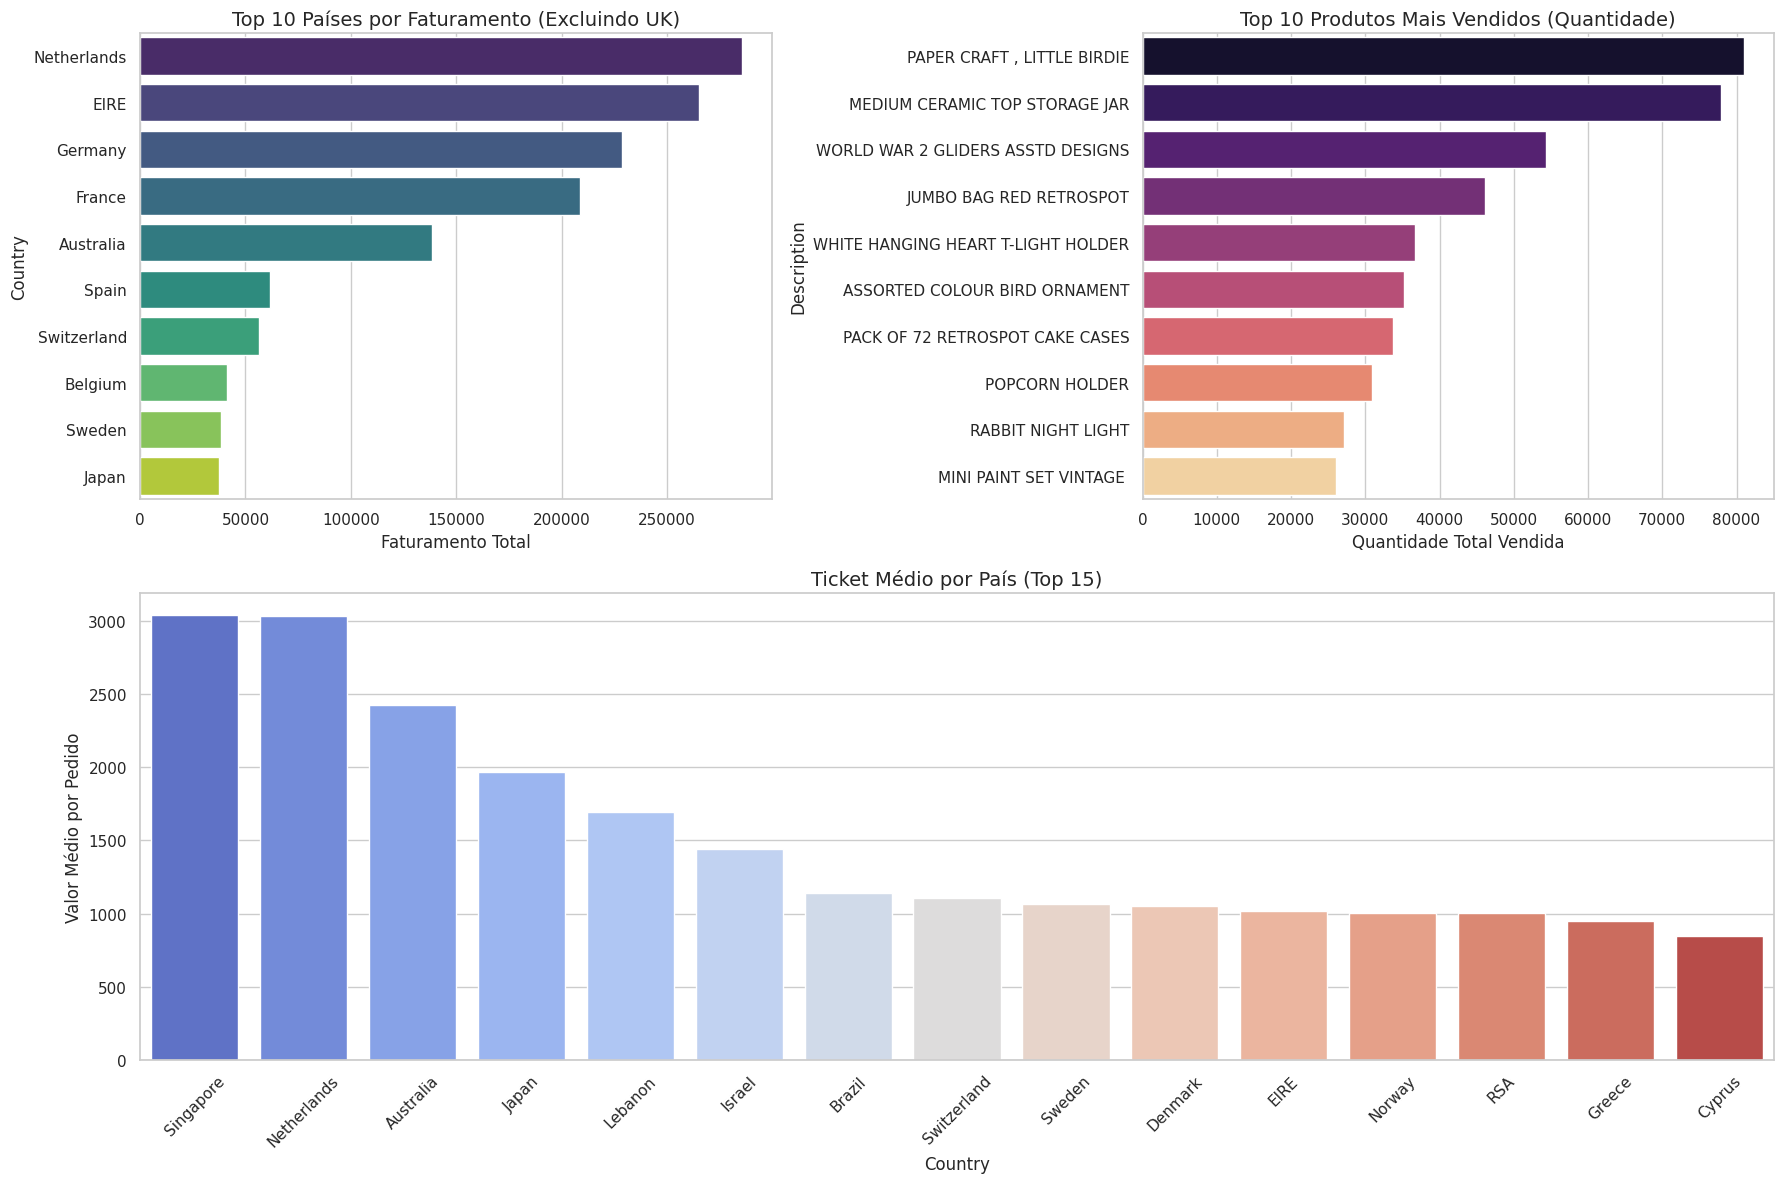


--- 💡 Insights Rápidos ---
O produto mais vendido é: 'PAPER CRAFT , LITTLE BIRDIE' com 80995 unidades.
O país com maior faturamento (fora UK) é: Netherlands.
O ticket médio geral da operação é: 479.56


In [5]:
# Configurando o layout dos gráficos
plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.5)

# ==============================================================================
# 1. TOP 10 PAÍSES POR FATURAMENTO (Excluindo UK para melhor visualização)
# ==============================================================================
# Nota: O Reino Unido geralmente domina 90% das vendas.
# Analisamos os demais para entender a expansão internacional.

plt.subplot(2, 2, 1)
top_countries = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Países por Faturamento (Excluindo UK)', fontsize=14)
plt.xlabel('Faturamento Total')

# ==============================================================================
# 2. TOP 10 PRODUTOS MAIS VENDIDOS (Volume)
# ==============================================================================

plt.subplot(2, 2, 2)
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Produtos Mais Vendidos (Quantidade)', fontsize=14)
plt.xlabel('Quantidade Total Vendida')

# ==============================================================================
# 3. TICKET MÉDIO POR PAÍS
# ==============================================================================
# Ticket Médio = Faturamento Total / Número de Pedidos Únicos

plt.subplot(2, 1, 2)
# Calculando faturamento e contagem de pedidos por país
country_stats = df.groupby('Country').agg({
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique'
})
country_stats['AverageTicket'] = country_stats['TotalPrice'] / country_stats['InvoiceNo']
top_tickets = country_stats['AverageTicket'].sort_values(ascending=False).head(15)

sns.barplot(x=top_tickets.index, y=top_tickets.values, palette='coolwarm')
plt.title('Ticket Médio por País (Top 15)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Valor Médio por Pedido')

plt.tight_layout()
plt.show()

# ==============================================================================
# RESUMO EM TEXTO
# ==============================================================================
print("\n--- 💡 Insights Rápidos ---")
print(f"O produto mais vendido é: '{top_products.index[0]}' com {top_products.values[0]} unidades.")
print(f"O país com maior faturamento (fora UK) é: {top_countries.index[0]}.")
print(f"O ticket médio geral da operação é: {df.groupby('InvoiceNo')['TotalPrice'].sum().mean():.2f}")

# ⏳ Etapa 4: Análise Temporal e Sazonalidade

Agora vamos investigar o comportamento das vendas através do tempo. Esta análise é dividida em quatro níveis de granularidade:

1.  **Sazonalidade Anual**: Comparação do faturamento entre os anos presentes na base.
2.  **Tendência Mensal**: Evolução do faturamento mês a mês para identificar picos sazonais (como Black Friday ou Natal).
3.  **Comportamento Semanal**: Quais dias da semana concentram o maior volume de compras?
4.  **Padrão Horário**: Em quais horários do dia nossos clientes estão mais ativos?

Para isso, faremos o *Feature Engineering* (Engenharia de Recursos), extraindo componentes específicos da coluna `InvoiceDate`.

/tmp/ipython-input-398/1623617687.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_sales.index, y=yearly_sales.values, ax=axes[0, 1], palette='Blues')
/tmp/ipython-input-398/1623617687.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_sales.index, y=day_sales.values, ax=axes[1, 0], palette='viridis')


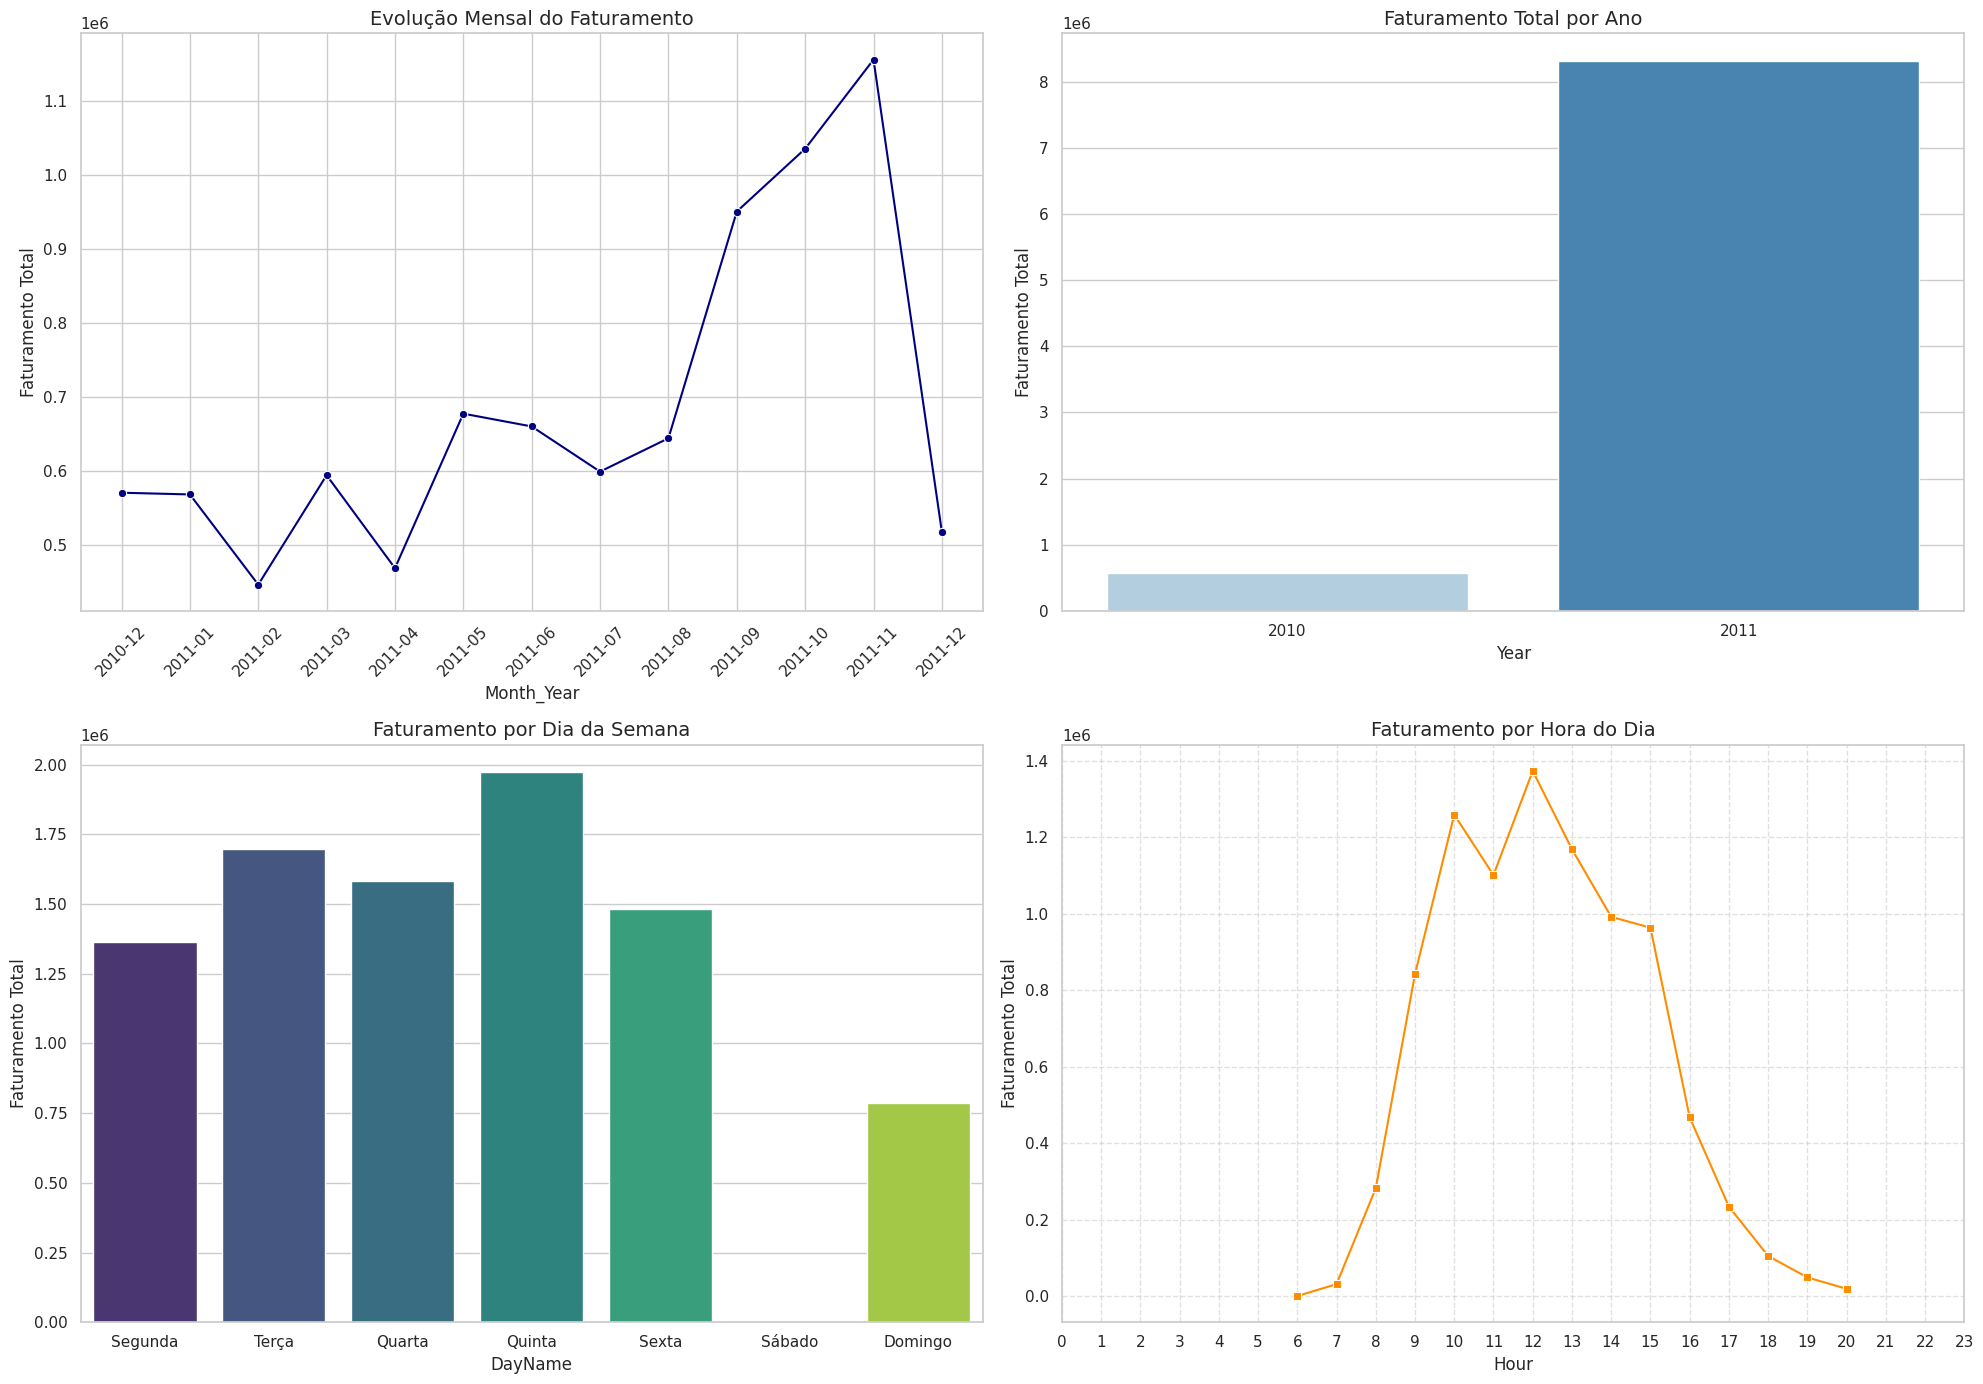


--- 💡 Conclusões da Análise Temporal ---
O mês com maior pico de vendas foi: 2011-11 (Faturamento: 1156205.61)
O dia da semana mais lucrativo é: Quinta
O horário de pico das transações inicia por volta das: 12h


In [6]:
# ==============================================================================
# 1. PREPARAÇÃO DOS DADOS TEMPORAIS (Feature Engineering)
# ==============================================================================

# Extraindo componentes de tempo
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek # 0=Segunda, 6=Domingo
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month_Year'] = df['InvoiceDate'].dt.to_period('M').astype(str) # Para linha do tempo contínua

# Mapeamento para nomes em português para facilitar a leitura dos gráficos
dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df['DayName'] = df['DayOfWeek'].map(dias_map)

# ==============================================================================
# 2. VISUALIZAÇÃO DA SAZONALIDADE
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
plt.subplots_adjust(hspace=0.4)

# --- GRÁFICO 1: Faturamento Mensal (Tendência) ---
monthly_sales = df.groupby('Month_Year')['TotalPrice'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', ax=axes[0, 0], color='navy')
axes[0, 0].set_title('Evolução Mensal do Faturamento', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Faturamento Total')

# --- GRÁFICO 2: Faturamento por Ano ---
yearly_sales = df.groupby('Year')['TotalPrice'].sum()
sns.barplot(x=yearly_sales.index, y=yearly_sales.values, ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Faturamento Total por Ano', fontsize=14)
axes[0, 1].set_ylabel('Faturamento Total')

# --- GRÁFICO 3: Sazonalidade por Dia da Semana ---
# Ordenando os dias corretamente
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
day_sales = df.groupby('DayName')['TotalPrice'].sum().reindex(ordem_dias)
sns.barplot(x=day_sales.index, y=day_sales.values, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Faturamento por Dia da Semana', fontsize=14)
axes[1, 0].set_ylabel('Faturamento Total')

# --- GRÁFICO 4: Distribuição por Hora do Dia ---
hour_sales = df.groupby('Hour')['TotalPrice'].sum()
sns.lineplot(x=hour_sales.index, y=hour_sales.values, marker='s', ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Faturamento por Hora do Dia', fontsize=14)
axes[1, 1].set_xticks(range(0, 24))
axes[1, 1].set_ylabel('Faturamento Total')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. ANÁLISE DE INSIGHTS
# ==============================================================================
print("\n--- 💡 Conclusões da Análise Temporal ---")
print(f"O mês com maior pico de vendas foi: {monthly_sales.idxmax()} (Faturamento: {monthly_sales.max():.2f})")
print(f"O dia da semana mais lucrativo é: {day_sales.idxmax()}")
print(f"O horário de pico das transações inicia por volta das: {hour_sales.idxmax()}h")

# 👥 Etapa 5: Análise de Clientes (Segmentação RFM)

Para entender quem são nossos clientes, utilizaremos o modelo **RFM**, que se baseia em três pilares:

1.  **Recência (R)**: Há quantos dias o cliente fez a sua última compra? (Quanto menor, melhor).
2.  **Frequência (F)**: Quantas vezes o cliente comprou connosco no período analisado? (Quanto maior, melhor).
3.  **Valor Monetário (M)**: Quanto o cliente gastou no total na nossa loja? (Quanto maior, melhor).

**O que faremos:**
* Calcular as métricas RFM por cliente.
* Atribuir notas de 1 a 5 para cada pilar (utilizando quintis).
* Segmentar os clientes em categorias como: **VIPs, Clientes Leais, Em Risco e Hibernando**.

/tmp/ipython-input-398/3735417495.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Spectral')


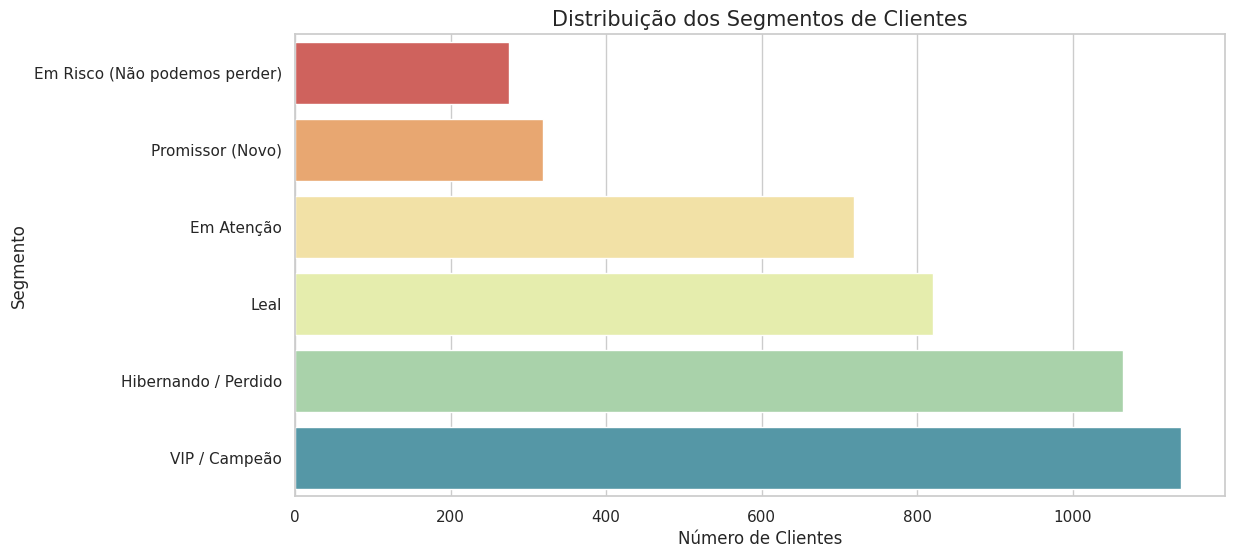


--- 🏆 Top 5 Clientes VIP (Maior Faturamento) ---


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segmento
CustomerID,,,,,,,,
14646,2,73,280206.02,5,5,5,55,VIP / Campeão
18102,1,60,259657.30,5,5,5,55,VIP / Campeão
17450,8,46,194390.79,5,5,5,55,VIP / Campeão
14911,1,201,143711.17,5,5,5,55,VIP / Campeão
12415,24,21,124914.53,4,5,5,45,VIP / Campeão


In [7]:
import datetime as dt

# ==============================================================================
# 1. PREPARAÇÃO: DEFINIR DATA DE REFERÊNCIA
# ==============================================================================

# Como o dataset é histórico, definimos a "data de hoje" como o dia seguinte
# à última compra registrada na base de dados.
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# ==============================================================================
# 2. CÁLCULO DAS MÉTRICAS RFM
# ==============================================================================

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recência
    'InvoiceNo': 'nunique',                                 # Frequência
    'TotalPrice': 'sum'                                     # Valor Monetário
})

# Renomear as colunas para facilitar o entendimento
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# ==============================================================================
# 3. ATRIBUIÇÃO DE NOTAS (QUINTIS)
# ==============================================================================

# Notas de 1 a 5 (5 é a melhor nota)
# Nota de Recência: quanto MENOR o número de dias, MELHOR a nota (invertemos os labels)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Notas de Frequência e Valor: quanto MAIOR o valor, MELHOR a nota
# Usamos rank(method='first') para evitar erros com muitos valores repetidos em Frequência
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Criar um Score Geral somando ou concatenando as notas
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# ==============================================================================
# 4. DEFINIÇÃO DE SEGMENTOS (ESTRATÉGIA DE NEGÓCIO)
# ==============================================================================

def segmentar_cliente(df_row):
    r = int(df_row['R_Score'])
    f = int(df_row['F_Score'])

    if r >= 4 and f >= 4:
        return 'VIP / Campeão'
    elif r >= 3 and f >= 3:
        return 'Leal'
    elif r >= 4 and f <= 2:
        return 'Promissor (Novo)'
    elif r <= 2 and f >= 4:
        return 'Em Risco (Não podemos perder)'
    elif r <= 2 and f <= 2:
        return 'Hibernando / Perdido'
    else:
        return 'Em Atenção'

rfm['Segmento'] = rfm.apply(segmentar_cliente, axis=1)

# ==============================================================================
# 5. VISUALIZAÇÃO DOS RESULTADOS
# ==============================================================================

plt.figure(figsize=(12, 6))
segment_counts = rfm['Segmento'].value_counts().sort_values(ascending=True)
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Spectral')
plt.title('Distribuição dos Segmentos de Clientes', fontsize=15)
plt.xlabel('Número de Clientes')
plt.show()

# Exibir os Top 5 clientes VIP por faturamento
print("\n--- 🏆 Top 5 Clientes VIP (Maior Faturamento) ---")
display(rfm[rfm['Segmento'] == 'VIP / Campeão'].sort_values('Monetary', ascending=False).head(5))

# 💰 Etapa 6: Análise de Faturamento por Segmento

Agora que segmentamos nossa base, vamos analisar a **distribuição do faturamento**. O objetivo é entender o peso financeiro de cada classe de cliente para o negócio.

Nesta análise, vamos:
1.  Agrupar o valor total gasto (`Monetary`) por cada segmento.
2.  Calcular a **participação percentual** de cada classe no faturamento total.
3.  Visualizar a discrepância entre os grupos para apoiar decisões de investimento em marketing e fidelização.

/tmp/ipython-input-398/1301121175.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faturamento_por_segmento.index, y=faturamento_por_segmento['Faturamento_Total'],


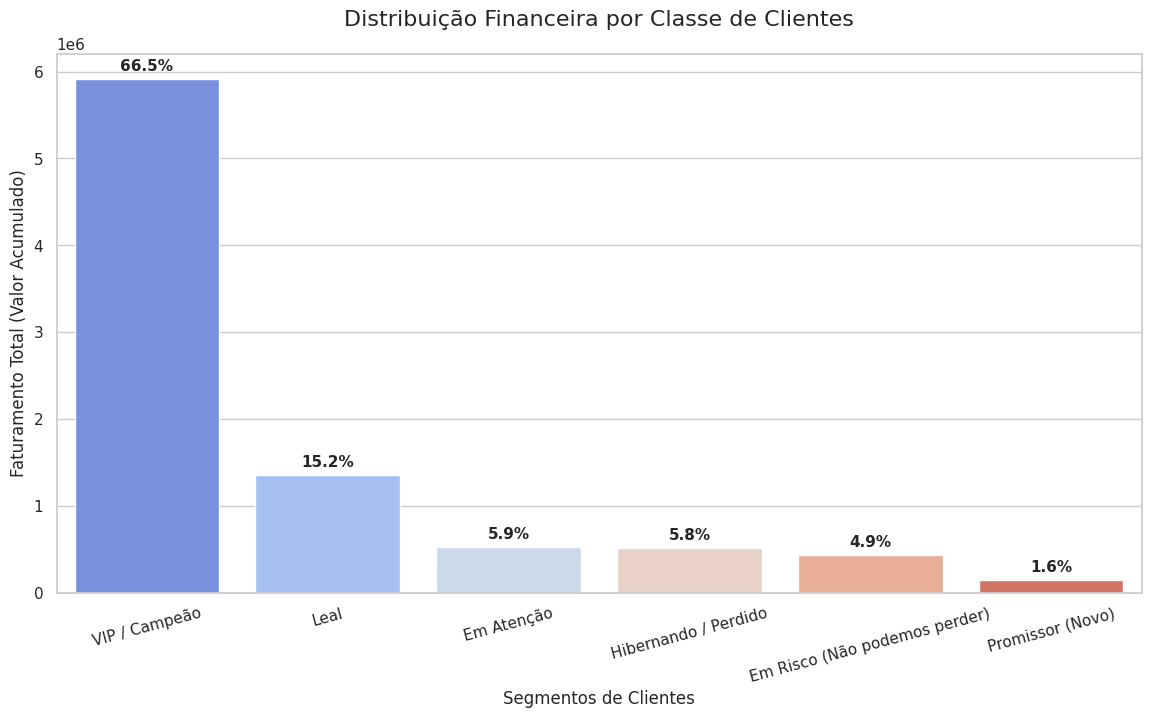


--- 📊 Tabela Resumo: Impacto por Segmento ---


,Faturamento_Total,Qtd_Clientes,Ticket_Medio_Segmento,Perc_Faturamento
Segmento,,,,
VIP / Campeão,"€ 5,913,422.08",1139,"€ 5,191.77",66.54%
Leal,"€ 1,351,084.30",821,"€ 1,645.66",15.20%
Em Atenção,"€ 527,521.35",719,€ 733.69,5.94%
Hibernando / Perdido,"€ 518,322.15",1065,€ 486.69,5.83%
Em Risco (Não podemos perder),"€ 431,639.27",275,"€ 1,569.60",4.86%
Promissor (Novo),"€ 145,219.74",319,€ 455.23,1.63%


In [8]:
# ==============================================================================
# 1. AGRREGAÇÃO FINANCEIRA POR SEGMENTO
# ==============================================================================

# Agrupando o faturamento por segmento
faturamento_por_segmento = rfm.groupby('Segmento')['Monetary'].agg(['sum', 'count', 'mean']).sort_values(by='sum', ascending=False)

# Renomeando colunas para clareza
faturamento_por_segmento.columns = ['Faturamento_Total', 'Qtd_Clientes', 'Ticket_Medio_Segmento']

# Calculando a porcentagem do faturamento total
total_geral = faturamento_por_segmento['Faturamento_Total'].sum()
faturamento_por_segmento['Perc_Faturamento'] = (faturamento_por_segmento['Faturamento_Total'] / total_geral) * 100

# ==============================================================================
# 2. VISUALIZAÇÃO DOS RESULTADOS
# ==============================================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Gráfico de Barras: Faturamento Total por Segmento
sns.barplot(x=faturamento_por_segmento.index, y=faturamento_por_segmento['Faturamento_Total'],
            palette='coolwarm', ax=ax1)

ax1.set_title('Distribuição Financeira por Classe de Clientes', fontsize=16, pad=20)
ax1.set_ylabel('Faturamento Total (Valor Acumulado)', fontsize=12)
ax1.set_xlabel('Segmentos de Clientes', fontsize=12)

# Adicionando os rótulos de porcentagem acima das barras
for i, p in enumerate(ax1.patches):
    percentage = faturamento_por_segmento['Perc_Faturamento'].iloc[i]
    ax1.annotate(f'{percentage:.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha = 'center', va = 'center',
                 xytext = (0, 9),
                 textcoords = 'offset points',
                 fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.show()

# ==============================================================================
# 3. TABELA DE RESUMO ESTRATÉGICO
# ==============================================================================

print("\n--- 📊 Tabela Resumo: Impacto por Segmento ---")
# Formatando a tabela para exibição financeira
resumo_formatado = faturamento_por_segmento.copy()
resumo_formatado['Faturamento_Total'] = resumo_formatado['Faturamento_Total'].map('€ {:,.2f}'.format)
resumo_formatado['Ticket_Medio_Segmento'] = resumo_formatado['Ticket_Medio_Segmento'].map('€ {:,.2f}'.format)
resumo_formatado['Perc_Faturamento'] = resumo_formatado['Perc_Faturamento'].map('{:.2f}%'.format)

display(resumo_formatado)

### 🏷️ Opção 1: Matriz de Recência vs. Frequência
Nesta visualização, cruzamos o quão recente o cliente comprou (R) com a frequência de compras (F).
* **Mapa 1 (Monetary)**: Identifica quais células da matriz trazem o maior volume financeiro total.
* **Mapa 2 (Ticket Médio)**: Identifica onde estão os clientes que gastam mais em cada transação individual.

Isso nos ajuda a ver se o nosso faturamento está vindo de muitos clientes comprando pouco, ou de poucos clientes comprando muito.

/tmp/ipython-input-398/67191341.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_monetary = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='sum')
/tmp/ipython-input-398/67191341.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_ticket = rfm.pivot_table(index='R_Score', columns='F_Score', values='Ticket_Avg', aggfunc='mean')


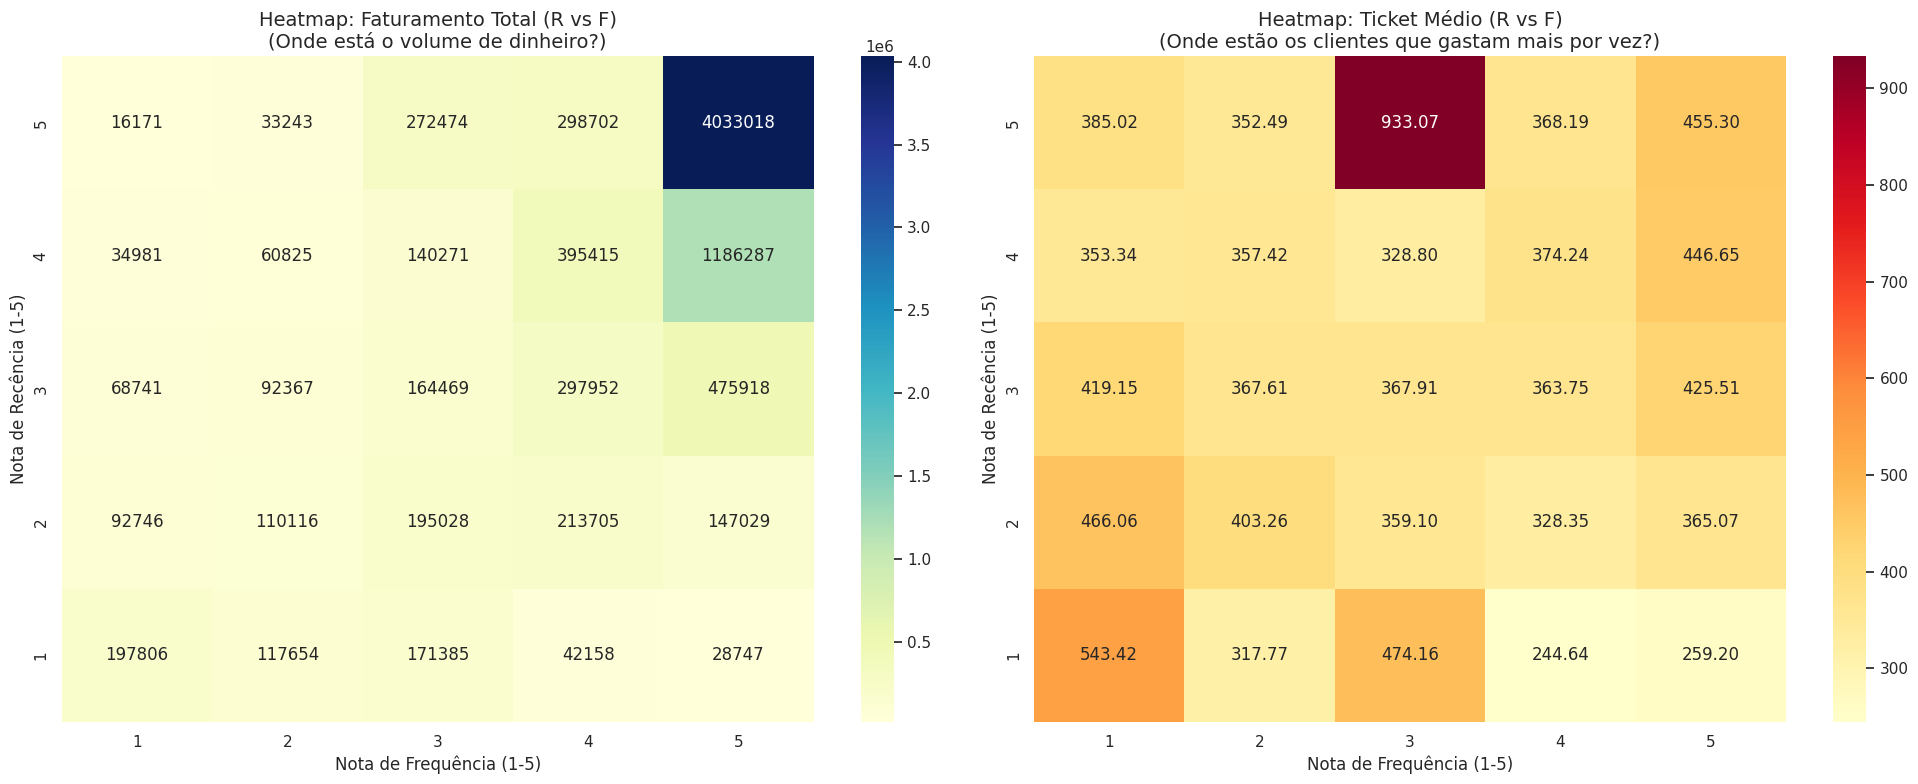

In [9]:
# Preparação dos dados para os heatmaps (Pivot Tables)
# Calculamos o faturamento total e o ticket médio (Monetary / Frequency)
rfm['Ticket_Avg'] = rfm['Monetary'] / rfm['Frequency']

# Pivot para Faturamento Total
pivot_monetary = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='sum')

# Pivot para Ticket Médio
pivot_ticket = rfm.pivot_table(index='R_Score', columns='F_Score', values='Ticket_Avg', aggfunc='mean')

# Plotagem
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Faturamento Total
sns.heatmap(pivot_monetary, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title('Heatmap: Faturamento Total (R vs F)\n(Onde está o volume de dinheiro?)', fontsize=14)
ax[0].set_xlabel('Nota de Frequência (1-5)')
ax[0].set_ylabel('Nota de Recência (1-5)')

# Gráfico 2: Ticket Médio
sns.heatmap(pivot_ticket, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax[1])
ax[1].set_title('Heatmap: Ticket Médio (R vs F)\n(Onde estão os clientes que gastam mais por vez?)', fontsize=14)
ax[1].set_xlabel('Nota de Frequência (1-5)')
ax[1].set_ylabel('Nota de Recência (1-5)')

plt.tight_layout()
plt.show()

### 📈 Opção 2: Matriz de Correlação de Pearson
Baseado no Guia de Visualização, este gráfico mostra o quão conectadas estão as nossas variáveis.
* Uma correlação de **1.0** indica que as variáveis crescem juntas.
* Uma correlação próxima de **0** indica que não há relação clara entre elas.

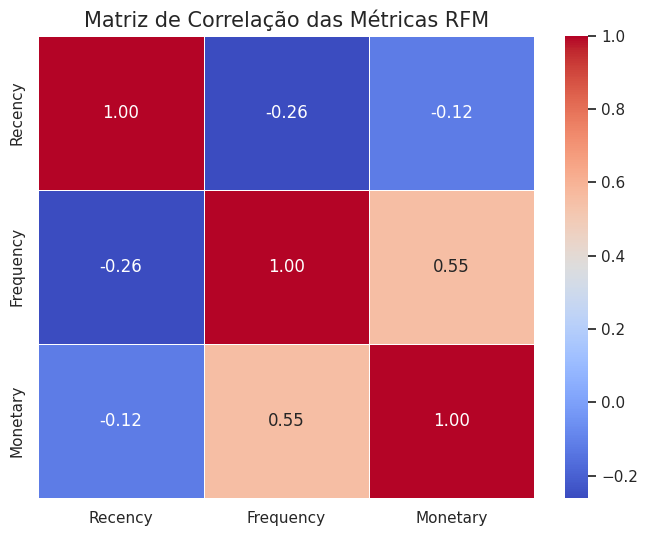

In [11]:
plt.figure(figsize=(8, 6))
correlation = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Métricas RFM', fontsize=15)
plt.show()

### 🎯 Opção 3: Mapa de Performance por Segmento (Resumo Executivo)
Este mapa resume as médias de cada métrica para os segmentos que criamos. É a visão ideal para apresentar em uma reunião de diretoria, pois mostra claramente a "saúde" de cada grupo de clientes.

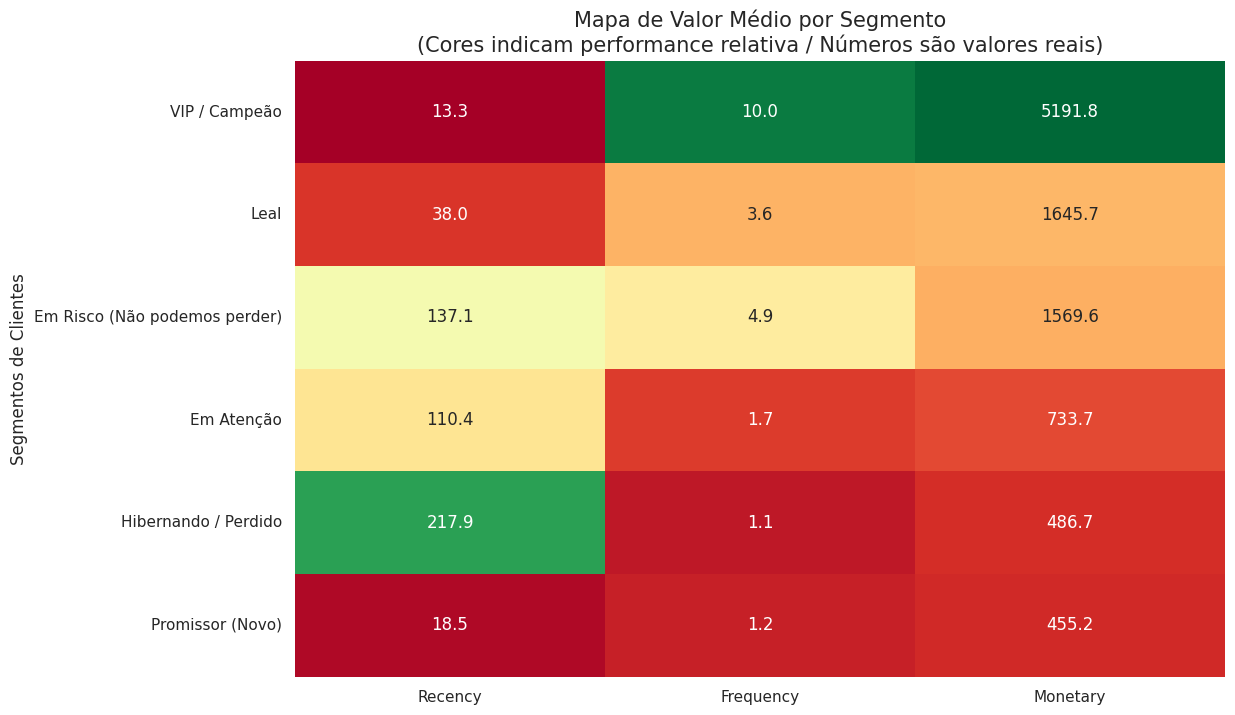

In [12]:
# Agrupando as médias por segmento
segment_analysis = rfm.groupby('Segmento').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Monetary', ascending=False)

# Normalizando os dados apenas para a escala do heatmap (para que uma métrica não abafe a outra)
# Mas exibiremos os valores reais no texto (annot)
segment_analysis_norm = (segment_analysis - segment_analysis.mean()) / segment_analysis.std()

plt.figure(figsize=(12, 8))
sns.heatmap(segment_analysis_norm, annot=segment_analysis, fmt=".1f", cmap="RdYlGn", cbar=False)
plt.title('Mapa de Valor Médio por Segmento\n(Cores indicam performance relativa / Números são valores reais)', fontsize=15)
plt.ylabel('Segmentos de Clientes')
plt.show()

### 📈 Análise de Curva ABC de Produtos
Esta análise classifica os produtos em três categorias baseadas no impacto financeiro:

1.  **Classe A**: Os itens mais valiosos. Geralmente representam cerca de **80% do faturamento**, embora sejam apenas ~20% do catálogo. Exigem controle de estoque rigoroso.
2.  **Classe B**: Itens de importância intermediária. Representam os próximos **15% do faturamento**.
3.  **Classe C**: A "cauda longa". São muitos itens (cerca de 50-70% do catálogo) que, somados, geram apenas **5% do faturamento**.

**Objetivo:** Identificar quais produtos são o motor financeiro da empresa.

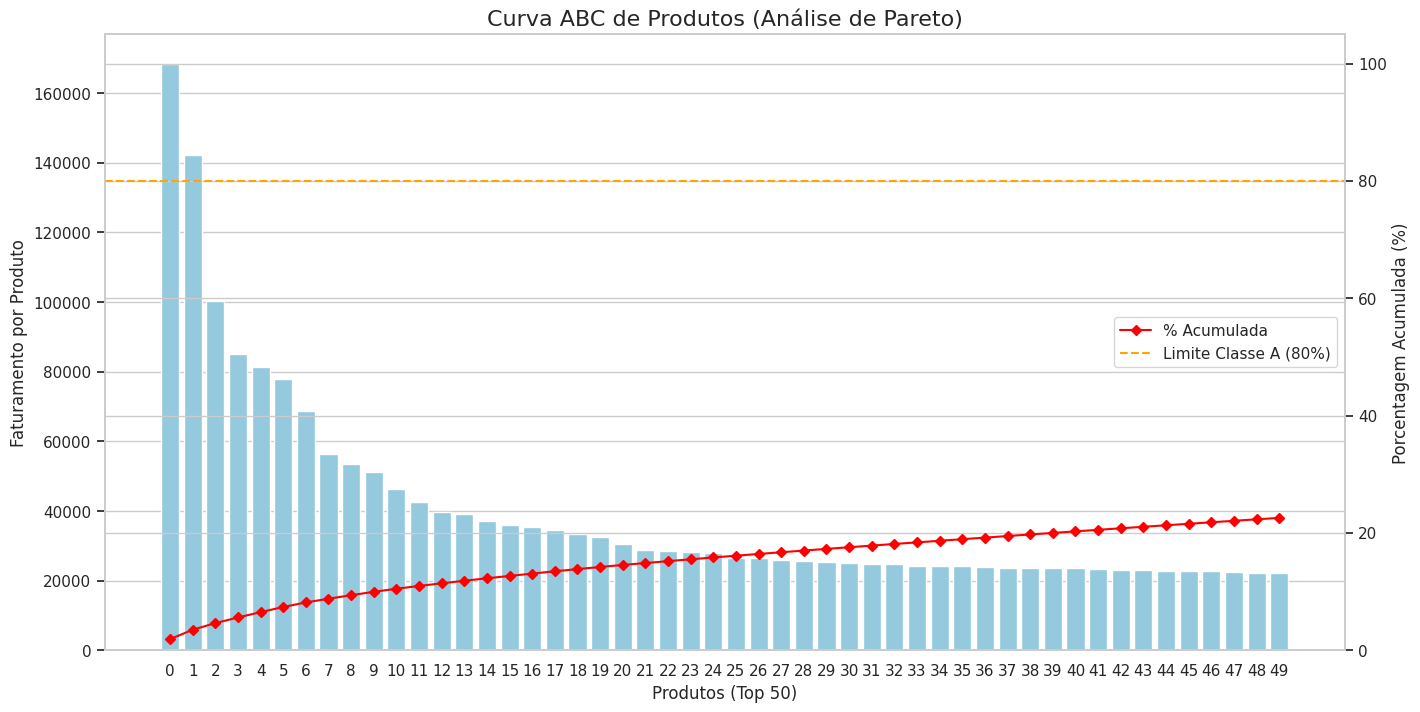


--- 📊 Resumo da Estrutura de Produtos ---


,Description,TotalPrice,%_Produtos,%_Faturamento
ABC_Class,,,,
A,809,"€ 7,108,393.97",20.9%,80.0%
B,959,"€ 1,334,391.65",24.7%,15.0%
C,2109,"€ 444,423.27",54.4%,5.0%


In [13]:
# ==============================================================================
# 1. CÁLCULO DA CURVA ABC
# ==============================================================================

# Agrupar faturamento por produto
df_abc = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Calcular o faturamento acumulado e a porcentagem acumulada
df_abc['Cumulative_Sales'] = df_abc['TotalPrice'].cumsum()
total_sales = df_abc['TotalPrice'].sum()
df_abc['Cumulative_Perc'] = (df_abc['Cumulative_Sales'] / total_sales) * 100

# Definir a classe baseada na porcentagem acumulada
def classify_abc(perc):
    if perc <= 80:
        return 'A'
    elif perc <= 95:
        return 'B'
    else:
        return 'C'

df_abc['ABC_Class'] = df_abc['Cumulative_Perc'].apply(classify_abc)

# ==============================================================================
# 2. VISUALIZAÇÃO (GRÁFICO DE PARETO)
# ==============================================================================

fig, ax1 = plt.subplots(figsize=(16, 8))

# Barras: Faturamento por produto (mostrando apenas os top 50 para não poluir)
sns.barplot(x=df_abc.index[:50], y=df_abc['TotalPrice'].iloc[:50], color='skyblue', ax=ax1)
ax1.set_ylabel('Faturamento por Produto', fontsize=12)
ax1.set_xlabel('Produtos (Top 50)', fontsize=12)
ax1.set_title('Curva ABC de Produtos (Análise de Pareto)', fontsize=16)

# Linha: Porcentagem Acumulada
ax2 = ax1.twinx()
ax2.plot(df_abc.index[:50], df_abc['Cumulative_Perc'].iloc[:50], color='red', marker='D', ms=5, label='% Acumulada')
ax2.axhline(y=80, color='orange', linestyle='--', label='Limite Classe A (80%)')
ax2.set_ylabel('Porcentagem Acumulada (%)', fontsize=12)
ax2.set_ylim(0, 105)

plt.legend(loc='center right')
plt.show()

# ==============================================================================
# 3. RESUMO ESTRATÉGICO ABC
# ==============================================================================

resumo_abc = df_abc.groupby('ABC_Class').agg({
    'Description': 'count',
    'TotalPrice': 'sum'
})
resumo_abc['%_Produtos'] = (resumo_abc['Description'] / resumo_abc['Description'].sum()) * 100
resumo_abc['%_Faturamento'] = (resumo_abc['TotalPrice'] / total_sales) * 100

print("\n--- 📊 Resumo da Estrutura de Produtos ---")
display(resumo_abc.style.format({'TotalPrice': '€ {:,.2f}', '%_Produtos': '{:.1f}%', '%_Faturamento': '{:.1f}%'}))